# Review Length Analysis for Amazon Movies and TV Reviews

This notebook studies whether reviewers who write longer comments behave differently from reviewers who write shorter comments in the Amazon Movies and TV 5-core review dataset.

**Core research question:** Do reviewers who write longer comments behave differently from reviewers who write shorter comments?

**Sub-questions**
1. What is the distribution of review comment length?
2. How does review length vary by star rating?
3. Are longer reviews more likely to receive helpful votes?
4. Do verified and unverified reviews differ in length?
5. Has review length changed over time?
6. Do heavy reviewers write longer or shorter comments than non-heavy reviewers?


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "review_length_outputs"
SLIDE_DIR = OUTPUT_DIR / "slide_figures"
OUTPUT_DIR.mkdir(exist_ok=True)
SLIDE_DIR.mkdir(exist_ok=True)

DATA_NAME = "Movies_and_TV_5.json"
RANDOM_SEED = 42
FIGSIZE = (10, 6)
SLIDE_FIGSIZE = (10.5, 6.5)
DPI = 300
SCATTER_SAMPLE_N = 200000

plt.style.use("ggplot")
plt.rcParams.update(
    {
        "figure.figsize": FIGSIZE,
        "figure.dpi": 120,
        "axes.titlesize": 16,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "axes.titleweight": "bold",
        "axes.grid": True,
        "grid.alpha": 0.25,
        "savefig.facecolor": "white",
        "axes.facecolor": "white",
    }
)

print(f"Project directory: {PROJECT_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Slide figure directory: {SLIDE_DIR}")


Project directory: a:\Projects\DATA 202
Output directory: a:\Projects\DATA 202\review_length_outputs
Slide figure directory: a:\Projects\DATA 202\review_length_outputs\slide_figures


## Data Loading

The Amazon Movies and TV file is line-delimited JSON, so the loader must read one JSON object per line. The code below also reports file size and memory usage before moving into analysis.

In [2]:
def resolve_data_path(project_dir: Path, data_name: str = DATA_NAME) -> Path:
    direct_path = project_dir / data_name
    nested_path = direct_path / data_name

    if direct_path.is_file():
        return direct_path

    if direct_path.is_dir() and nested_path.is_file():
        print(
            "Note: the dataset was not found as a same-folder file. "
            f"Using the nested extracted file at {nested_path}."
        )
        return nested_path

    raise FileNotFoundError(
        "Movies_and_TV_5.json must be in the same folder as the notebook "
        f"({project_dir}). If you extracted the dataset into a folder, move the file "
        "Movies_and_TV_5.json next to this notebook or keep the nested extracted file layout."
    )


data_path = resolve_data_path(PROJECT_DIR)
file_size_gb = data_path.stat().st_size / (1024 ** 3)
print(f"Dataset path: {data_path}")
print(f"Dataset size on disk: {file_size_gb:,.2f} GB")

try:
    df_raw = pd.read_json(data_path, lines=True)
except ValueError as exc:
    raise ValueError(
        "Failed to read Movies_and_TV_5.json as line-delimited JSON. "
        "Make sure the file contains one JSON object per line."
    ) from exc

print(f"Raw dataframe shape: {df_raw.shape}")
print("Columns:")
print(df_raw.columns.tolist())
raw_memory_mb = df_raw.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Approximate dataframe memory usage: {raw_memory_mb:,.2f} MB")
display(df_raw.head())


Note: the dataset was not found as a same-folder file. Using the nested extracted file at a:\Projects\DATA 202\Movies_and_TV_5.json\Movies_and_TV_5.json.
Dataset path: a:\Projects\DATA 202\Movies_and_TV_5.json\Movies_and_TV_5.json
Dataset size on disk: 2.32 GB
Raw dataframe shape: (3410019, 12)
Columns:
['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'style', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'vote', 'image']
Approximate dataframe memory usage: 3,545.28 MB


,overall,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,vote,image
0,5,True,"11 9, 2012",A2M1CU2IRZG0K9,0005089549,{'Format:': ' VHS Tape'},Terri,So sorry I didn't purchase this years ago when...,Amazing!,1352419200,NaN,NaN
1,5,True,"12 30, 2011",AFTUJYISOFHY6,0005089549,{'Format:': ' VHS Tape'},Melissa D. Abercrombie,Believe me when I tell you that you will recei...,Great Gospel VHS of the Cathedrals!,1325203200,NaN,NaN
2,5,True,"04 21, 2005",A3JVF9Y53BEOGC,000503860X,{'Format:': ' DVD'},Anthony Thompson,"I have seen X live many times, both in the ear...",A great document of a great band,1114041600,11,NaN
3,5,True,"04 6, 2005",A12VPEOEZS1KTC,000503860X,{'Format:': ' DVD'},JadeRain,"I was so excited for this! Finally, a live co...",YES!! X LIVE!!,1112745600,5,NaN
4,5,True,"12 3, 2010",ATLZNVLYKP9AZ,000503860X,{'Format:': ' DVD'},T. Fisher,X is one of the best punk bands ever. I don't ...,X have still got it,1291334400,5,NaN


## Data Cleaning and Feature Engineering

This section creates clean analytic variables for rating, date, helpfulness, review length, reviewer activity, and length-group categories. Missing review text is kept and treated as zero-length text so that missing text does not silently drop observations.

In [3]:
def safe_series(frame: pd.DataFrame, column: str, default_value=np.nan) -> pd.Series:
    if column in frame.columns:
        return frame[column]
    return pd.Series(default_value, index=frame.index)


def parse_vote(value):
    if pd.isna(value):
        return 0
    if isinstance(value, str):
        value = value.replace(",", "").strip()
        if value == "":
            return 0
    return pd.to_numeric(value, errors="coerce")


def word_count(text: str) -> int:
    text = str(text).strip()
    if not text:
        return 0
    return len(text.split())


df = df_raw.copy()

missing_review_text_count = safe_series(df, "reviewText").isna().sum()
missing_vote_count = safe_series(df, "vote").isna().sum()

df["rating"] = pd.to_numeric(safe_series(df, "overall"), errors="coerce")
df["review_text"] = safe_series(df, "reviewText", "").fillna("").astype(str)
df["summary_text"] = safe_series(df, "summary", "").fillna("").astype(str)
df["date"] = pd.to_datetime(safe_series(df, "unixReviewTime"), unit="s", errors="coerce")
df["year"] = df["date"].dt.year
df["helpful_votes"] = safe_series(df, "vote").apply(parse_vote)
df["helpful_votes"] = pd.to_numeric(df["helpful_votes"], errors="coerce").fillna(0)
df["verified"] = safe_series(df, "verified", False).fillna(False).astype(bool)

df["review_length_chars"] = df["review_text"].str.len()
df["review_length_words"] = df["review_text"].apply(word_count)
df["summary_length_words"] = df["summary_text"].apply(word_count)
df["log_review_length_words"] = np.log1p(df["review_length_words"])
df["log_helpful_votes"] = np.log1p(df["helpful_votes"])

df = df.dropna(subset=["rating", "reviewerID", "asin", "date"]).copy()
df = df[df["rating"].between(1, 5)].copy()
df["year"] = df["date"].dt.year.astype(int)

df["reviewer_review_count"] = df.groupby("reviewerID")["reviewerID"].transform("size")
df["item_review_count"] = df.groupby("asin")["asin"].transform("size")

heavy_threshold = df["reviewer_review_count"].quantile(0.9)
df["heavy_reviewer"] = df["reviewer_review_count"] >= heavy_threshold

length_ranks = df["review_length_words"].rank(method="first")
df["length_group"] = pd.qcut(length_ranks, q=3, labels=["Short", "Medium", "Long"])

quality_summary = pd.Series(
    {
        "rows_after_cleaning": int(len(df)),
        "missing_review_text_count": int(missing_review_text_count),
        "missing_vote_count": int(missing_vote_count),
        "rating_min": float(df["rating"].min()),
        "rating_max": float(df["rating"].max()),
        "date_min": df["date"].min(),
        "date_max": df["date"].max(),
        "unique_reviewers": int(df["reviewerID"].nunique()),
        "unique_items": int(df["asin"].nunique()),
        "heavy_reviewer_threshold_reviews": float(heavy_threshold),
    }
)

display(quality_summary.to_frame(name="value"))
display(
    df[
        [
            "rating",
            "verified",
            "date",
            "year",
            "helpful_votes",
            "review_length_chars",
            "review_length_words",
            "log_review_length_words",
            "summary_length_words",
            "reviewer_review_count",
            "item_review_count",
            "heavy_reviewer",
            "length_group",
        ]
    ].head()
)


,value
rows_after_cleaning,3410019
missing_review_text_count,1581
missing_vote_count,2768010
rating_min,1.0000
rating_max,5.0000
date_min,1997-12-02 00:00:00
date_max,2018-10-01 00:00:00
unique_reviewers,297529
unique_items,60175
heavy_reviewer_threshold_reviews,109.0000


,rating,verified,date,year,helpful_votes,review_length_chars,review_length_words,log_review_length_words,summary_length_words,reviewer_review_count,item_review_count,heavy_reviewer,length_group
0,5,True,2012-11-09,2012,0,337,61,4.1271,1,6,4,False,Long
1,5,True,2011-12-30,2011,0,202,39,3.6889,6,5,4,False,Medium
2,5,True,2005-04-21,2005,11,241,50,3.9318,7,31,9,False,Medium
3,5,True,2005-04-06,2005,5,862,165,5.1120,3,38,9,False,Long
4,5,True,2010-12-03,2010,5,2336,389,5.9661,5,19,9,False,Long


## Summary Tables and Export Files

Because review length is strongly right-skewed, both mean and median are reported throughout. The tables below are also exported as CSV files so they can be reused directly in slides, appendices, or the written report.

In [4]:
def describe_length(series: pd.Series) -> pd.Series:
    return pd.Series(
        {
            "count": int(series.count()),
            "mean": float(series.mean()),
            "median": float(series.median()),
            "std": float(series.std()),
            "min": float(series.min()),
            "q1": float(series.quantile(0.25)),
            "q3": float(series.quantile(0.75)),
            "max": float(series.max()),
        }
    )


review_length_summary_overall = describe_length(df["review_length_words"]).to_frame().T

review_length_by_rating = (
    df.groupby("rating")["review_length_words"]
    .apply(describe_length)
    .unstack()
    .reset_index()
    .sort_values("rating")
)

review_length_by_verified = (
    df.groupby("verified")["review_length_words"]
    .apply(describe_length)
    .unstack()
    .reset_index()
)
review_length_by_verified["verified_label"] = review_length_by_verified["verified"].map({False: "Unverified", True: "Verified"})

review_length_by_heavy_reviewer = (
    df.groupby("heavy_reviewer")["review_length_words"]
    .apply(describe_length)
    .unstack()
    .reset_index()
)
review_length_by_heavy_reviewer["reviewer_group"] = review_length_by_heavy_reviewer["heavy_reviewer"].map({False: "Non-heavy", True: "Heavy"})

helpful_votes_by_length_group = (
    df.groupby("length_group", observed=False)
    .agg(
        review_count=("reviewerID", "size"),
        mean_helpful_votes=("helpful_votes", "mean"),
        median_helpful_votes=("helpful_votes", "median"),
        mean_rating=("rating", "mean"),
        median_rating=("rating", "median"),
        median_review_length_words=("review_length_words", "median"),
    )
    .reset_index()
)

yearly_review_length_summary = (
    df.groupby("year")
    .agg(
        yearly_review_count=("reviewerID", "size"),
        mean_review_length_words=("review_length_words", "mean"),
        median_review_length_words=("review_length_words", "median"),
        mean_log_review_length_words=("log_review_length_words", "mean"),
    )
    .reset_index()
    .sort_values("year")
)

review_length_summary_overall.to_csv(OUTPUT_DIR / "review_length_summary_overall.csv", index=False)
review_length_by_rating.to_csv(OUTPUT_DIR / "review_length_by_rating.csv", index=False)
review_length_by_verified.to_csv(OUTPUT_DIR / "review_length_by_verified.csv", index=False)
review_length_by_heavy_reviewer.to_csv(OUTPUT_DIR / "review_length_by_heavy_reviewer.csv", index=False)
helpful_votes_by_length_group.to_csv(OUTPUT_DIR / "helpful_votes_by_length_group.csv", index=False)
yearly_review_length_summary.to_csv(OUTPUT_DIR / "yearly_review_length_summary.csv", index=False)

print("Overall review length summary")
display(review_length_summary_overall)

print("Review length by rating")
display(review_length_by_rating)

print("Review length by verified status")
display(review_length_by_verified)

print("Review length by heavy reviewer status")
display(review_length_by_heavy_reviewer)

print("Helpful votes and ratings by length group")
display(helpful_votes_by_length_group)

print("Yearly review count and review length summary")
display(yearly_review_length_summary)


Overall review length summary


,count,mean,median,std,min,q1,q3,max
0,"3,410,019.0000",81.1488,25.0000,161.6872,0.0000,7.0000,78.0000,"5,983.0000"


Review length by rating


,rating,count,mean,median,std,min,q1,q3,max
0,1,"193,169.0000",90.0792,40.0000,147.3048,0.0000,14.0000,106.0000,"4,694.0000"
1,2,"172,439.0000",116.4045,48.0000,177.0064,0.0000,16.0000,143.0000,"4,487.0000"
2,3,"349,700.0000",111.5700,38.0000,183.4105,0.0000,12.0000,133.0000,"5,965.0000"
3,4,"665,920.0000",106.2149,33.0000,187.9743,0.0000,10.0000,119.0000,"5,773.0000"
4,5,"2,028,791.0000",63.8307,21.0000,145.0407,0.0000,5.0000,54.0000,"5,983.0000"


Review length by verified status


...

,heavy_reviewer,count,mean,median,std,min,q1,q3,max,reviewer_group
0,False,"3,067,740.0000",62.2674,22.0000,126.0931,0.0000,6.0000,59.0000,"5,965.0000",Non-heavy
1,True,"342,279.0000",250.3767,169.0000,293.4565,0.0000,55.0000,348.0000,"5,983.0000",Heavy


Helpful votes and ratings by length group


,length_group,review_count,mean_helpful_votes,median_helpful_votes,mean_rating,median_rating,median_review_length_words
0,Short,1136673,0.0379,0.0000,4.4331,5.0000,4.0000
1,Medium,1136673,0.3848,0.0000,4.2652,5.0000,25.0000
2,Long,1136673,4.6583,0.0000,3.9657,4.0000,133.0000


Yearly review count and review length summary


,year,yearly_review_count,mean_review_length_words,median_review_length_words,mean_log_review_length_words
0,1997,1,263.0000,263.0000,5.5759
1,1998,224,118.0714,86.0000,4.4999
2,1999,3578,130.1358,106.0000,4.6403
3,2000,20071,175.0705,136.0000,4.9008
4,2001,25666,209.6567,162.0000,5.0661
5,2002,30832,226.0198,175.0000,5.1293
6,2003,32734,240.9288,186.0000,5.1781
7,2004,45422,249.1746,188.0000,5.1970
8,2005,53293,260.0521,186.0000,5.1924
9,2006,49428,250.9883,176.0000,5.1301


## Visualization Setup

The figures below use consistent sizing, readable typography, high-resolution export, and capped or log-scaled views when the raw distributions are extremely skewed. Each figure is saved both for the report and, where useful, as a simplified slide-ready version.

In [5]:
MAIN_PNG_FILES = [
    "review_length_histogram.png",
    "review_length_by_rating_boxplot.png",
    "median_review_length_by_rating.png",
    "mean_review_length_by_rating.png",
    "review_length_by_verified_boxplot.png",
    "review_length_vs_helpful_votes.png",
    "median_review_length_by_year.png",
    "median_review_length_heavy_vs_nonheavy.png",
    "average_rating_by_length_group.png",
]

SLIDE_PNG_FILES = [
    "slide_review_length_distribution.png",
    "slide_review_length_by_rating.png",
    "slide_review_length_vs_helpful_votes.png",
    "slide_verified_vs_unverified_length.png",
    "slide_heavy_vs_nonheavy_length.png",
    "slide_review_length_over_time.png",
]

CSV_FILES = [
    "review_length_summary_overall.csv",
    "review_length_by_rating.csv",
    "review_length_by_verified.csv",
    "review_length_by_heavy_reviewer.csv",
    "helpful_votes_by_length_group.csv",
    "yearly_review_length_summary.csv",
    "statistical_tests_summary.csv",
    "regression_coefficients_summary.csv",
]


def save_figure(fig, filename: str, slide_filename: str = None, slide=False):
    target_dir = SLIDE_DIR if slide else OUTPUT_DIR
    fig.savefig(target_dir / filename, dpi=DPI, bbox_inches="tight", facecolor="white")
    if slide_filename is not None:
        fig.savefig(SLIDE_DIR / slide_filename, dpi=DPI, bbox_inches="tight", facecolor="white")


def final_axis_cleanup(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


length_cap = 500
ratings_sorted = sorted(df["rating"].dropna().unique())
verified_order = [False, True]
verified_labels = ["Unverified", "Verified"]
heavy_order = [False, True]
heavy_labels = ["Non-heavy", "Heavy"]

median_length_by_rating = df.groupby("rating")["review_length_words"].median().sort_index()
mean_length_by_rating = df.groupby("rating")["review_length_words"].mean().sort_index()
median_length_by_heavy = df.groupby("heavy_reviewer")["review_length_words"].median().reindex(heavy_order)
average_rating_by_length = df.groupby("length_group", observed=False)["rating"].mean().reindex(["Short", "Medium", "Long"])
verified_medians = df.groupby("verified")["review_length_words"].median().reindex(verified_order)


## Figure 1. Review Length Distribution

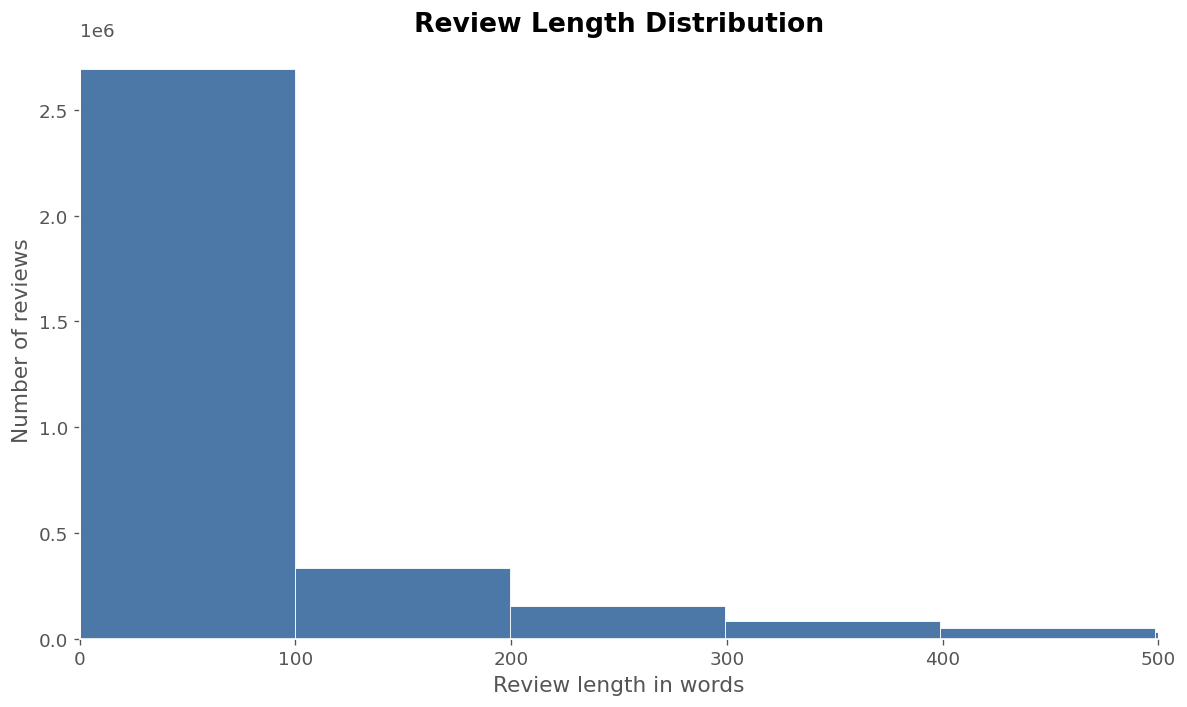

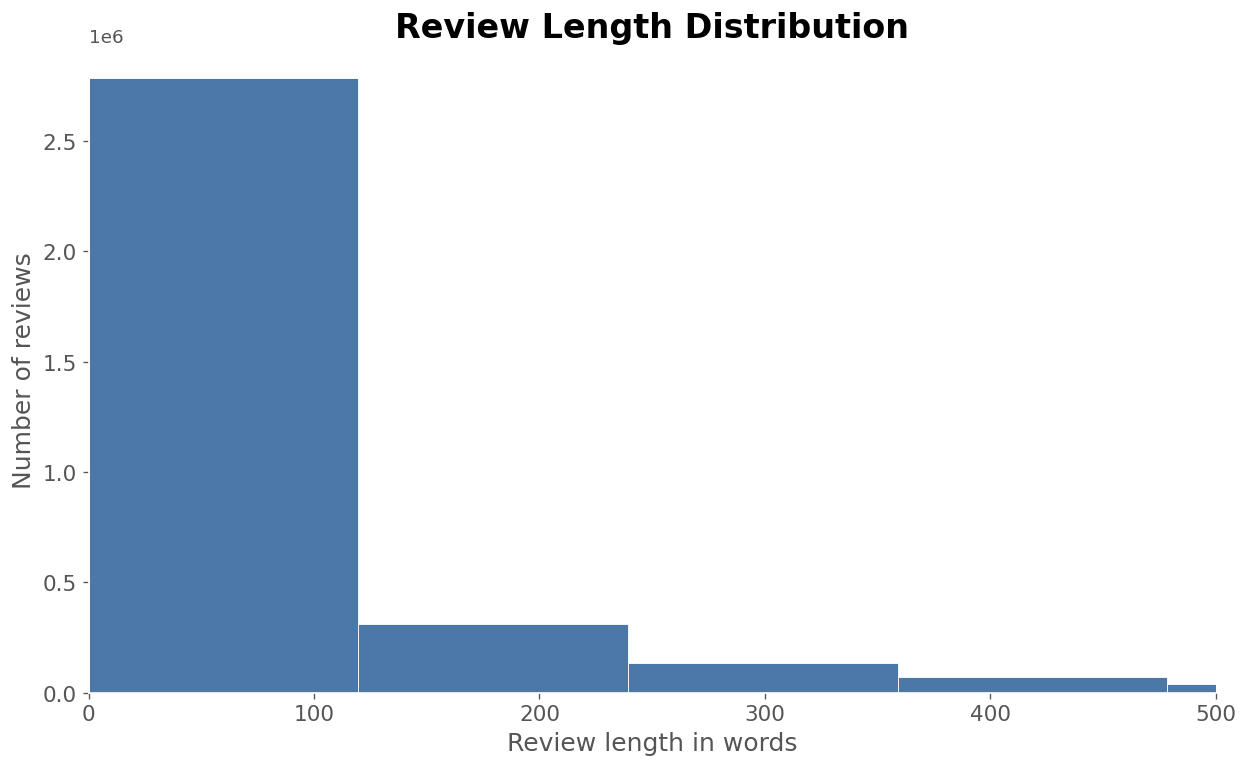

In [21]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(df["review_length_words"], bins=60, color="#4C78A8", edgecolor="white")
ax.set_xlim(0, length_cap)
ax.set_title("Review Length Distribution")
ax.set_xlabel("Review length in words")
ax.set_ylabel("Number of reviews")
final_axis_cleanup(ax)
fig.tight_layout()
save_figure(fig, "review_length_histogram.png")

slide_fig, slide_ax = plt.subplots(figsize=SLIDE_FIGSIZE)
slide_ax.hist(df["review_length_words"], bins=50, color="#4C78A8", edgecolor="white")
slide_ax.set_xlim(0, length_cap)
slide_ax.set_title("Review Length Distribution")
slide_ax.set_xlabel("Review length in words")
slide_ax.set_ylabel("Number of reviews")
slide_ax.tick_params(labelsize=13)
slide_ax.title.set_fontsize(20)
slide_ax.xaxis.label.set_size(15)
slide_ax.yaxis.label.set_size(15)
final_axis_cleanup(slide_ax)
slide_fig.tight_layout()
save_figure(slide_fig, "slide_review_length_distribution.png", slide=True)
plt.show()


*Caption:* Review length is strongly right-skewed. Most reviews are short, while a small minority of reviewers write much longer comments, so capped views are useful for presentation.

## Figure 2. Review Length by Rating

C:\Users\Administrator\AppData\Local\Temp\ipykernel_7124\1923283801.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(rating_groups, labels=[str(int(r)) for r in ratings_sorted], showfliers=False, patch_artist=True,


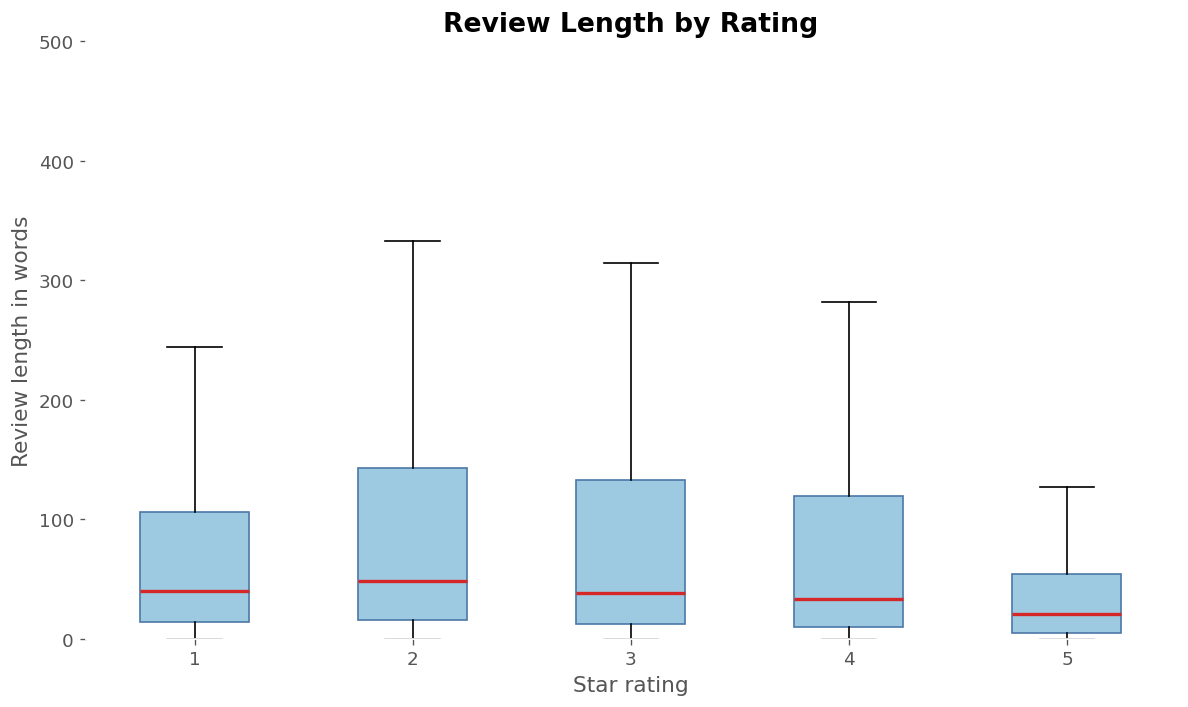

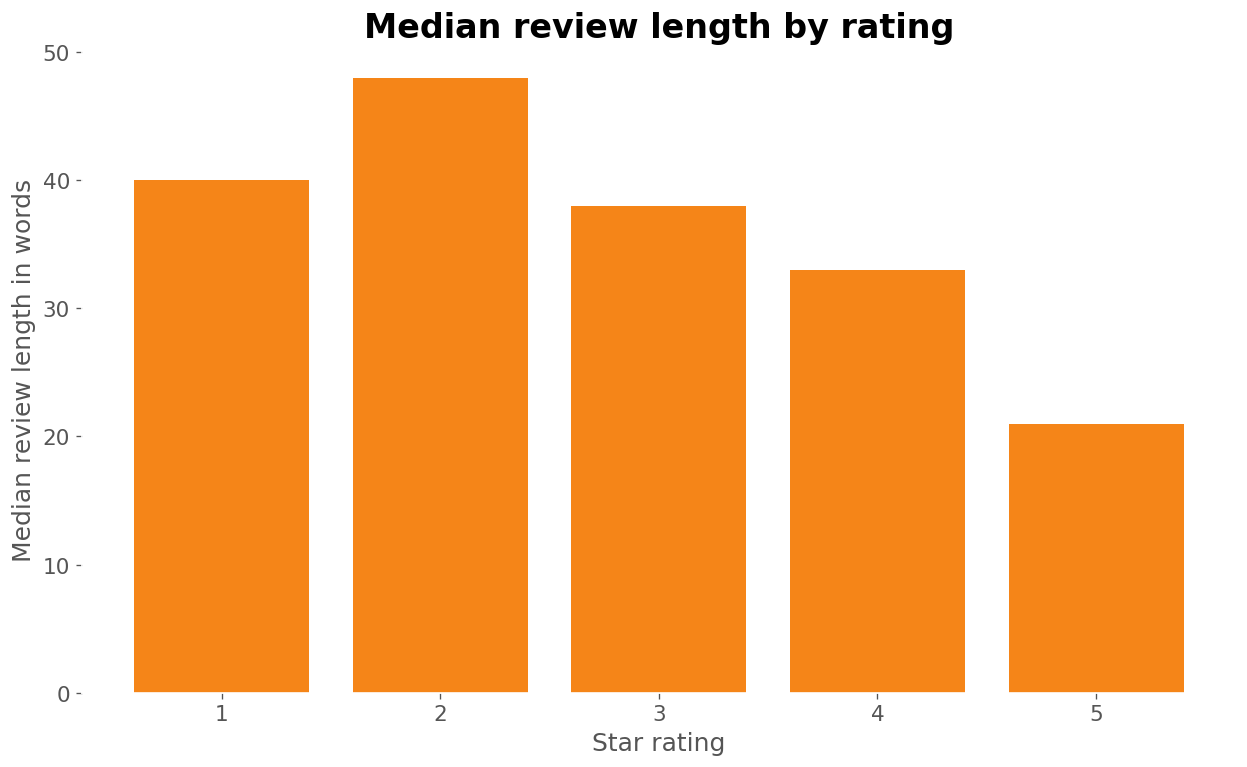

In [23]:
fig, ax = plt.subplots(figsize=FIGSIZE)
rating_groups = [df.loc[df["rating"] == rating, "review_length_words"] for rating in ratings_sorted]
ax.boxplot(rating_groups, labels=[str(int(r)) for r in ratings_sorted], showfliers=False, patch_artist=True,
           boxprops=dict(facecolor="#9ECAE1", color="#4C78A8"), medianprops=dict(color="#D62728", linewidth=2))
ax.set_ylim(0, length_cap)
ax.set_title("Review Length by Rating")
ax.set_xlabel("Star rating")
ax.set_ylabel("Review length in words")
final_axis_cleanup(ax)
fig.tight_layout()
save_figure(fig, "review_length_by_rating_boxplot.png")

slide_fig, slide_ax = plt.subplots(figsize=SLIDE_FIGSIZE)
slide_ax.bar(median_length_by_rating.index.astype(int).astype(str), median_length_by_rating.values, color="#F58518")
slide_ax.set_title("Median review length by rating")
slide_ax.set_xlabel("Star rating")
slide_ax.set_ylabel("Median review length in words")
slide_ax.tick_params(labelsize=13)
slide_ax.title.set_fontsize(20)
slide_ax.xaxis.label.set_size(15)
slide_ax.yaxis.label.set_size(15)
final_axis_cleanup(slide_ax)
slide_fig.tight_layout()
save_figure(slide_fig, "slide_review_length_by_rating.png", slide=True)
plt.show()


*Caption:* The rating boxplot shows that review length differs across score levels, with lower-star reviews often containing more text. The capped y-axis keeps the central pattern readable despite extreme long-review outliers.

## Figure 3. Median Review Length by Rating

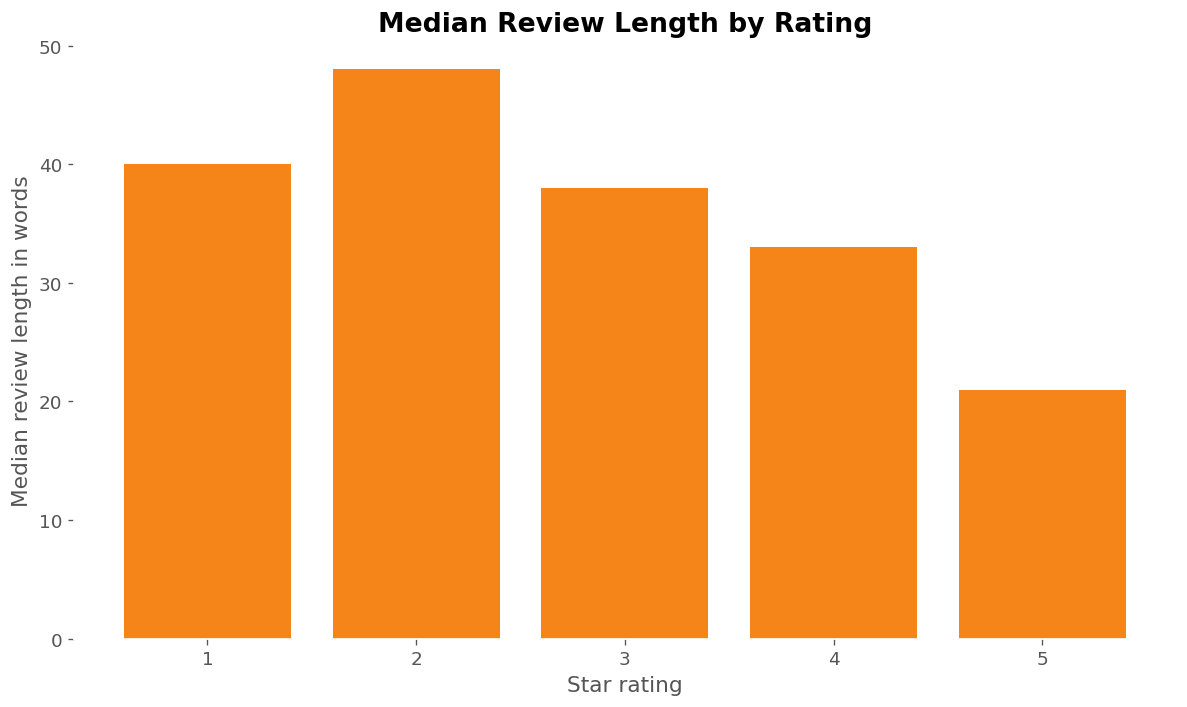

In [24]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(median_length_by_rating.index.astype(int).astype(str), median_length_by_rating.values, color="#F58518")
ax.set_title("Median Review Length by Rating")
ax.set_xlabel("Star rating")
ax.set_ylabel("Median review length in words")
final_axis_cleanup(ax)
fig.tight_layout()
save_figure(fig, "median_review_length_by_rating.png")
plt.show()


*Caption:* Median review length is a robust summary for skewed text-length data. It highlights the typical amount of writing at each star level without being dominated by a few very long reviews.

## Figure 4. Mean Review Length by Rating

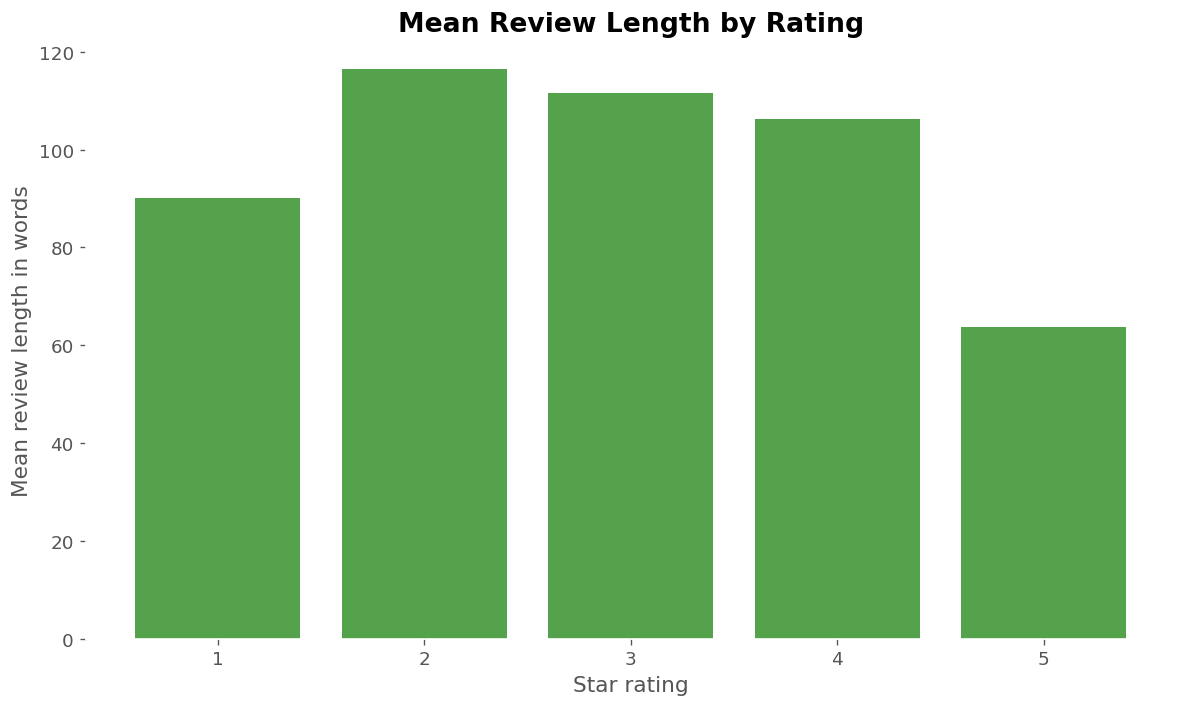

In [25]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(mean_length_by_rating.index.astype(int).astype(str), mean_length_by_rating.values, color="#54A24B")
ax.set_title("Mean Review Length by Rating")
ax.set_xlabel("Star rating")
ax.set_ylabel("Mean review length in words")
final_axis_cleanup(ax)
fig.tight_layout()
save_figure(fig, "mean_review_length_by_rating.png")
plt.show()


*Caption:* Reporting mean and median together is a useful robustness check. If they tell a similar story, the rating pattern is less likely to be an artifact of a handful of unusually long reviews.

## Figure 5. Verified Versus Unverified Review Length

C:\Users\Administrator\AppData\Local\Temp\ipykernel_7124\1632395690.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(verified_groups, labels=verified_labels, showfliers=False, patch_artist=True,


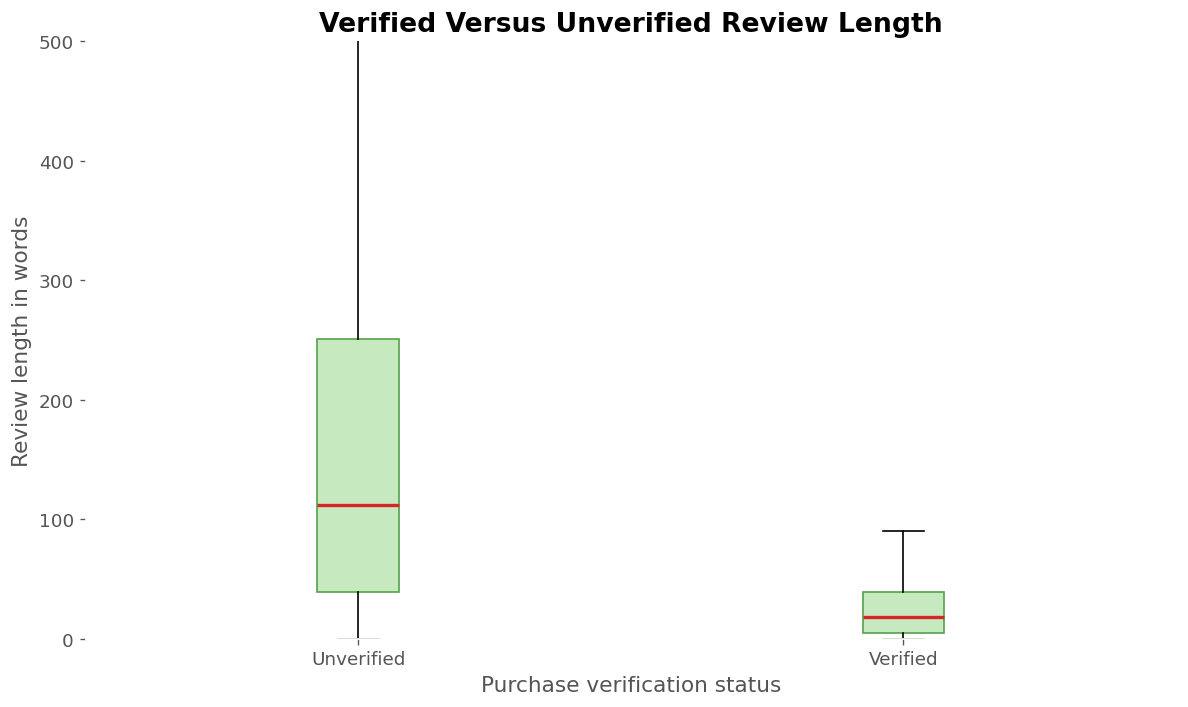

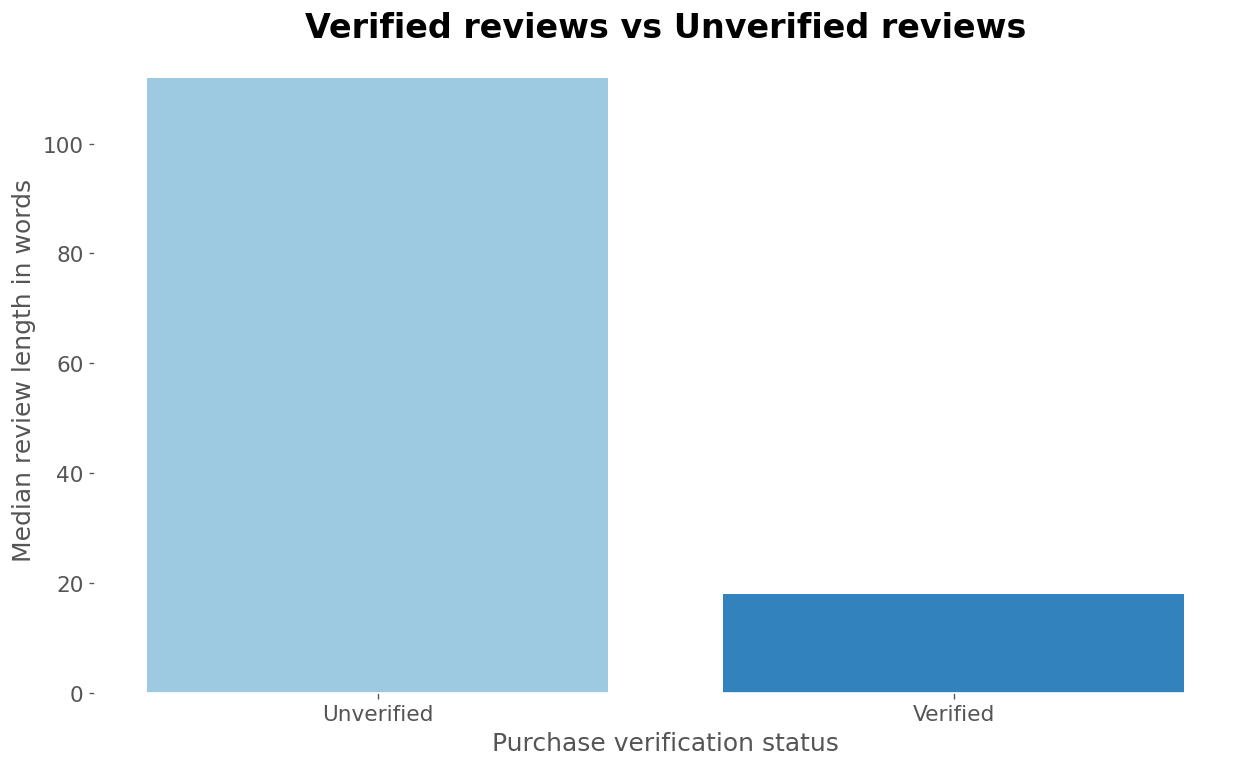

In [27]:
fig, ax = plt.subplots(figsize=FIGSIZE)
verified_groups = [df.loc[df["verified"] == status, "review_length_words"] for status in verified_order]
ax.boxplot(verified_groups, labels=verified_labels, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor="#C7E9C0", color="#54A24B"), medianprops=dict(color="#D62728", linewidth=2))
ax.set_ylim(0, length_cap)
ax.set_title("Verified Versus Unverified Review Length")
ax.set_xlabel("Purchase verification status")
ax.set_ylabel("Review length in words")
final_axis_cleanup(ax)
fig.tight_layout()
save_figure(fig, "review_length_by_verified_boxplot.png")

slide_fig, slide_ax = plt.subplots(figsize=SLIDE_FIGSIZE)
slide_ax.bar(verified_labels, verified_medians.values, color=["#9ECAE1", "#3182BD"])
slide_ax.set_title("Verified reviews vs Unverified reviews")
slide_ax.set_xlabel("Purchase verification status")
slide_ax.set_ylabel("Median review length in words")
slide_ax.tick_params(labelsize=13)
slide_ax.title.set_fontsize(20)
slide_ax.xaxis.label.set_size(15)
slide_ax.yaxis.label.set_size(15)
final_axis_cleanup(slide_ax)
slide_fig.tight_layout()
save_figure(slide_fig, "slide_verified_vs_unverified_length.png", slide=True)
plt.show()


*Caption:* Verified and unverified reviews differ sharply in typical length. This suggests that purchase verification is associated with distinct reviewing behavior, not just a small statistical difference.

## Figure 6. Review Length and Helpfulness

Scatter plot sampled 200,000 rows for readability.


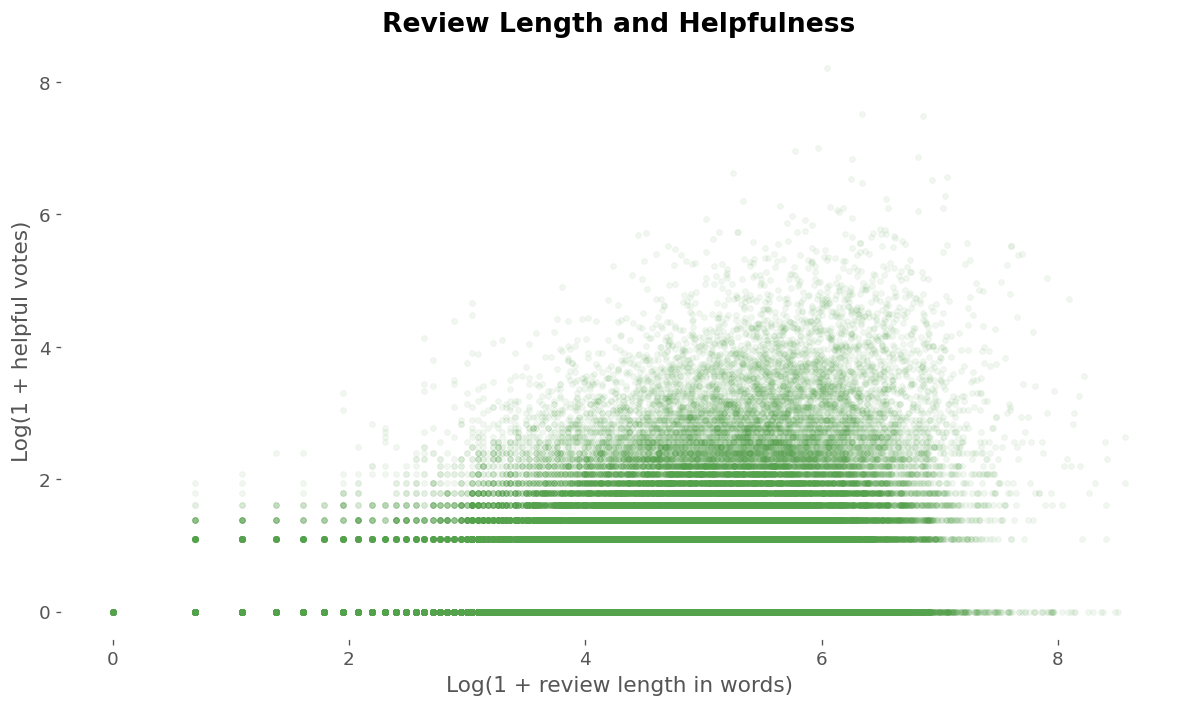

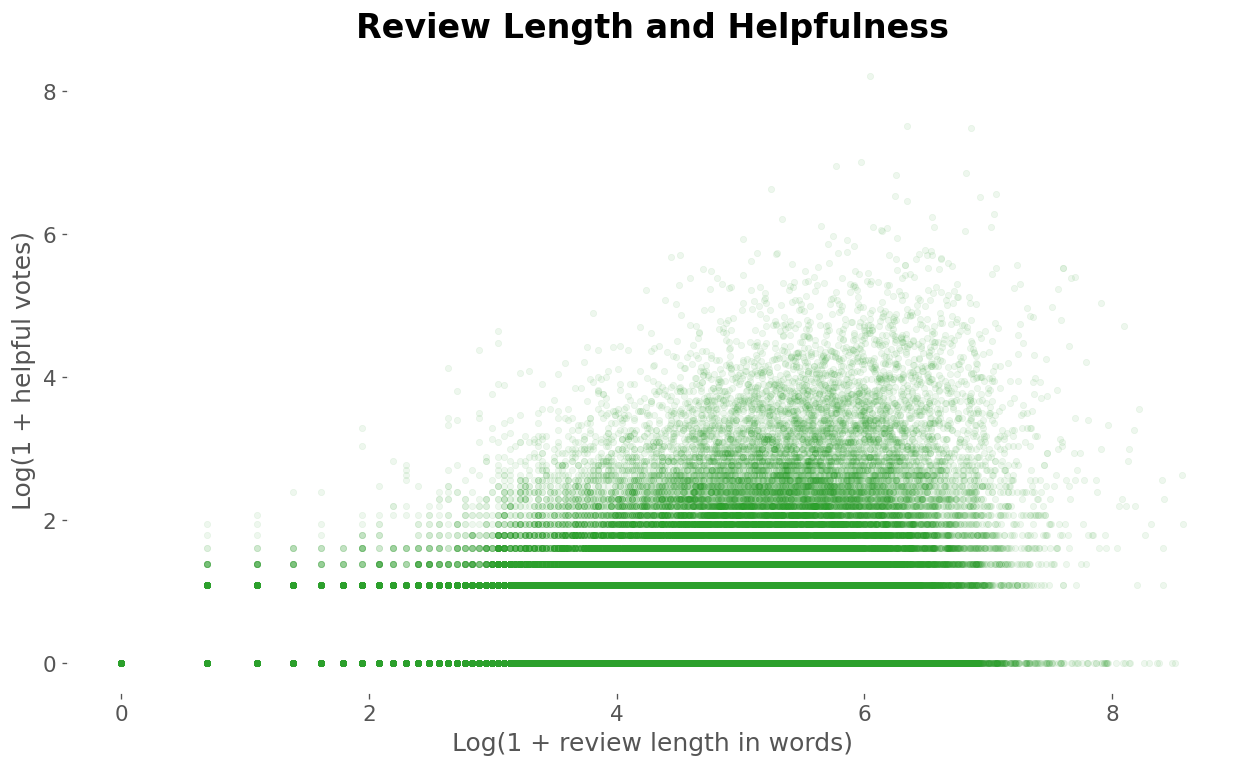

In [28]:
scatter_df = df[["log_review_length_words", "log_helpful_votes"]].dropna()
if len(scatter_df) > SCATTER_SAMPLE_N:
    scatter_df = scatter_df.sample(SCATTER_SAMPLE_N, random_state=RANDOM_SEED)
    print(f"Scatter plot sampled {SCATTER_SAMPLE_N:,} rows for readability.")

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.scatter(
    scatter_df["log_review_length_words"],
    scatter_df["log_helpful_votes"],
    alpha=0.08,
    s=12,
    color="#54A24B",
)
ax.set_title("Review Length and Helpfulness")
ax.set_xlabel("Log(1 + review length in words)")
ax.set_ylabel("Log(1 + helpful votes)")
final_axis_cleanup(ax)
fig.tight_layout()
save_figure(fig, "review_length_vs_helpful_votes.png")

slide_fig, slide_ax = plt.subplots(figsize=SLIDE_FIGSIZE)
slide_ax.scatter(
    scatter_df["log_review_length_words"],
    scatter_df["log_helpful_votes"],
    alpha=0.08,
    s=14,
    color="#2CA02C",
)
slide_ax.set_title("Review Length and Helpfulness")
slide_ax.set_xlabel("Log(1 + review length in words)")
slide_ax.set_ylabel("Log(1 + helpful votes)")
slide_ax.tick_params(labelsize=13)
slide_ax.title.set_fontsize(20)
slide_ax.xaxis.label.set_size(15)
slide_ax.yaxis.label.set_size(15)
final_axis_cleanup(slide_ax)
slide_fig.tight_layout()
save_figure(slide_fig, "slide_review_length_vs_helpful_votes.png", slide=True)
plt.show()


*Caption:* The helpfulness relationship is easier to see on log scales because both review length and helpful-vote counts are skewed. The upward pattern indicates that longer comments are generally associated with more reader engagement.

## Figure 7. Review Length Over Time

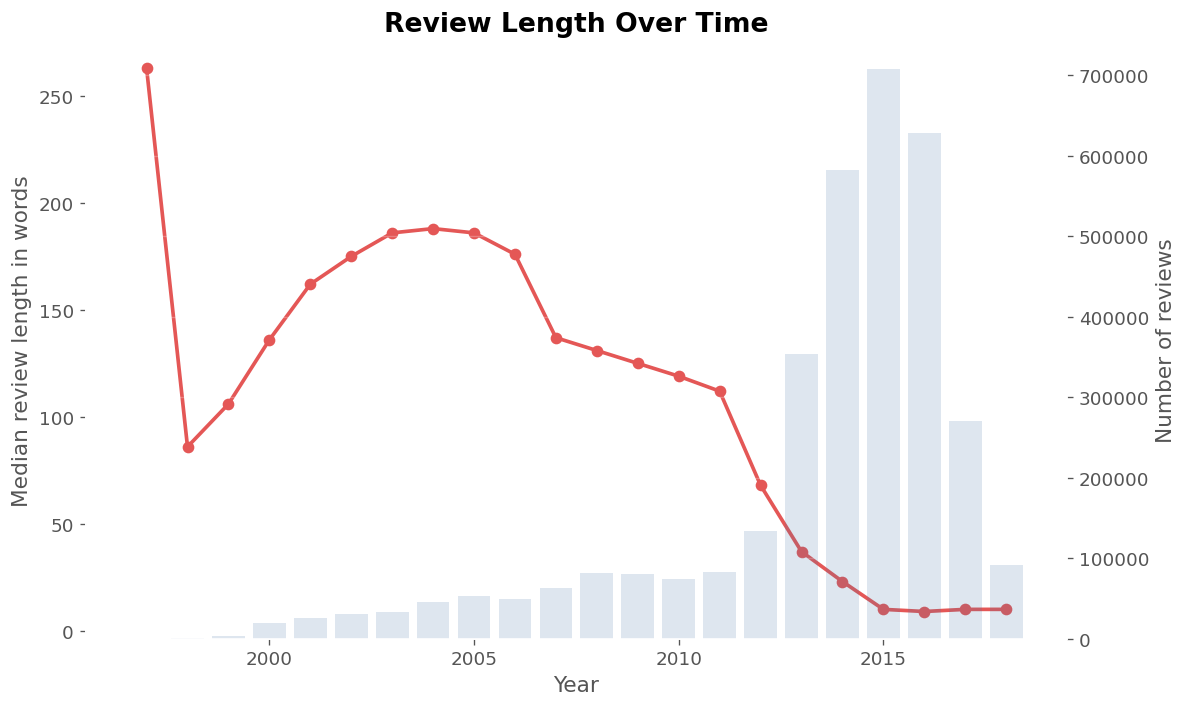

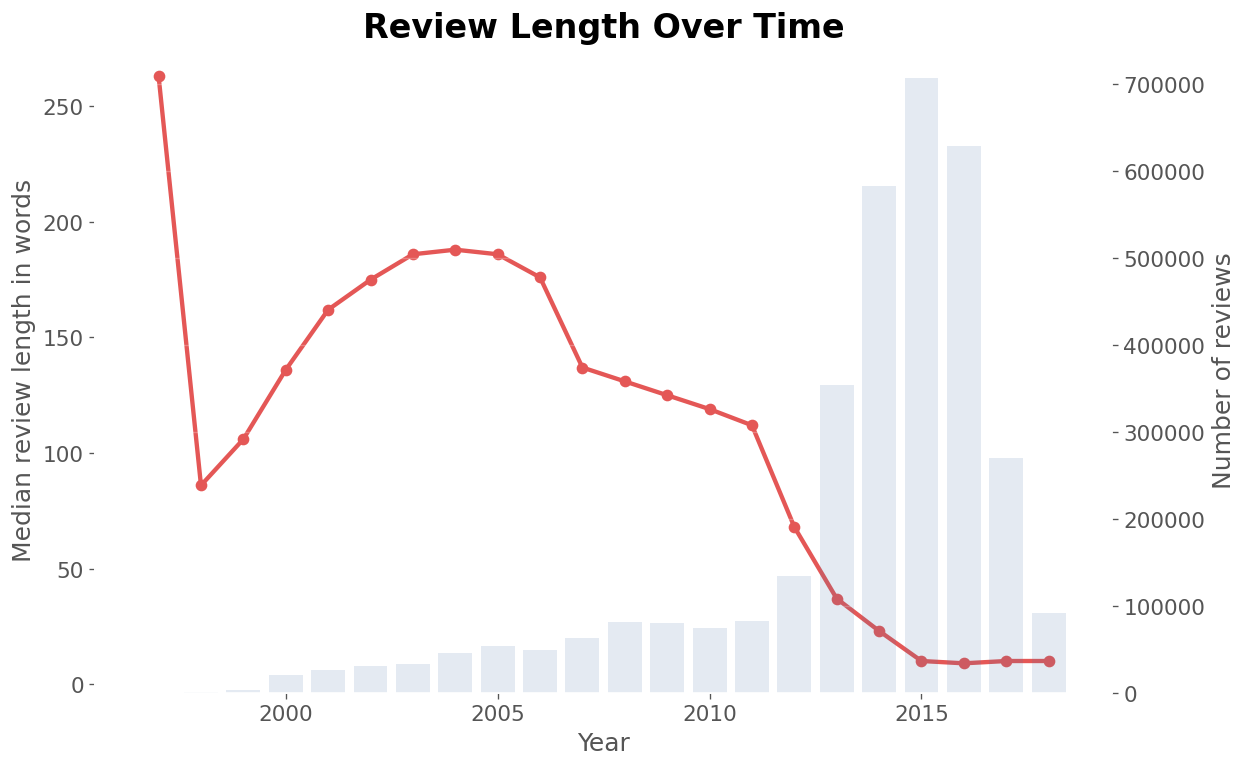

In [30]:
fig, ax1 = plt.subplots(figsize=FIGSIZE)
ax2 = ax1.twinx()
ax1.plot(
    yearly_review_length_summary["year"],
    yearly_review_length_summary["median_review_length_words"],
    marker="o",
    linewidth=2.2,
    color="#E45756",
)
ax2.bar(
    yearly_review_length_summary["year"],
    yearly_review_length_summary["yearly_review_count"],
    alpha=0.18,
    color="#4C78A8",
)
ax1.set_title("Review Length Over Time")
ax1.set_xlabel("Year")
ax1.set_ylabel("Median review length in words")
ax2.set_ylabel("Number of reviews")
final_axis_cleanup(ax1)
ax2.spines["top"].set_visible(False)
fig.tight_layout()
save_figure(fig, "median_review_length_by_year.png")

slide_fig, slide_ax1 = plt.subplots(figsize=SLIDE_FIGSIZE)
slide_ax2 = slide_ax1.twinx()
slide_ax1.plot(
    yearly_review_length_summary["year"],
    yearly_review_length_summary["median_review_length_words"],
    marker="o",
    linewidth=2.6,
    color="#E45756",
)
slide_ax2.bar(
    yearly_review_length_summary["year"],
    yearly_review_length_summary["yearly_review_count"],
    alpha=0.15,
    color="#4C78A8",
)
slide_ax1.set_title("Review Length Over Time")
slide_ax1.set_xlabel("Year")
slide_ax1.set_ylabel("Median review length in words")
slide_ax2.set_ylabel("Number of reviews")
slide_ax1.tick_params(labelsize=13)
slide_ax2.tick_params(labelsize=13)
slide_ax1.title.set_fontsize(20)
slide_ax1.xaxis.label.set_size(15)
slide_ax1.yaxis.label.set_size(15)
slide_ax2.yaxis.label.set_size(15)
final_axis_cleanup(slide_ax1)
slide_ax2.spines["top"].set_visible(False)
slide_fig.tight_layout()
save_figure(slide_fig, "slide_review_length_over_time.png", slide=True)
plt.show()


*Caption:* Median review length falls substantially over the life of the dataset, but early years also have far fewer reviews. Those low-volume years should be interpreted cautiously because small sample sizes can make early medians unstable.

## Figure 8. Heavy Versus Non-heavy Reviewers

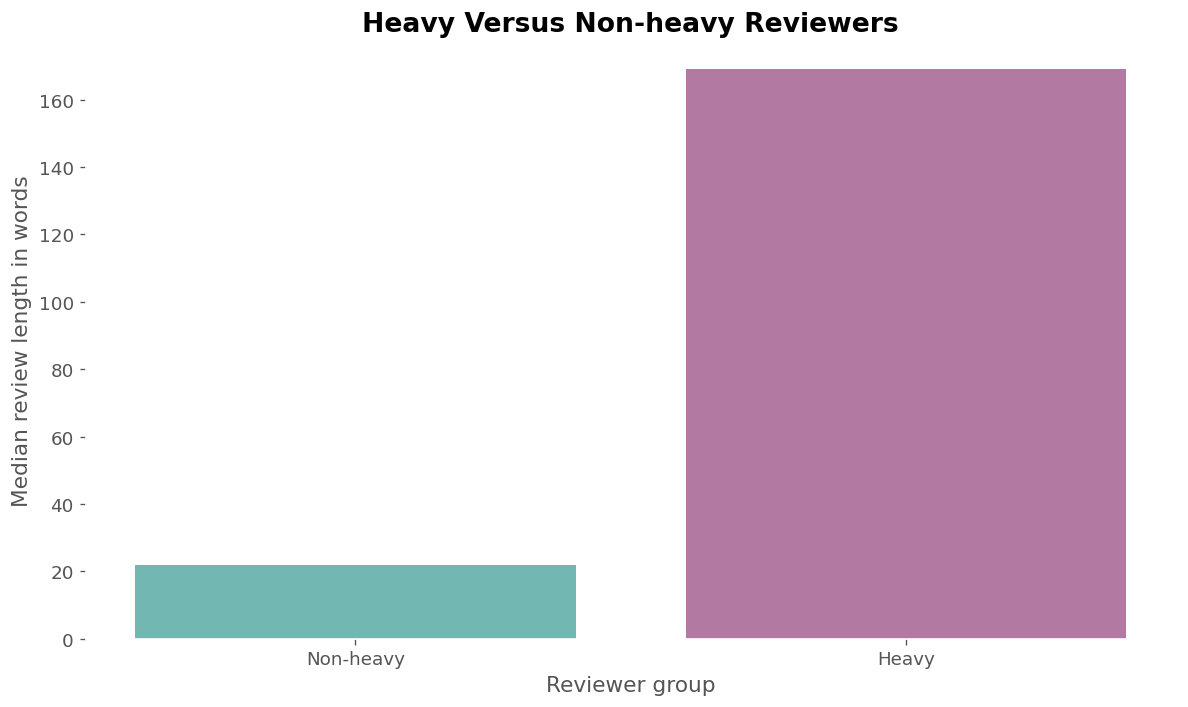

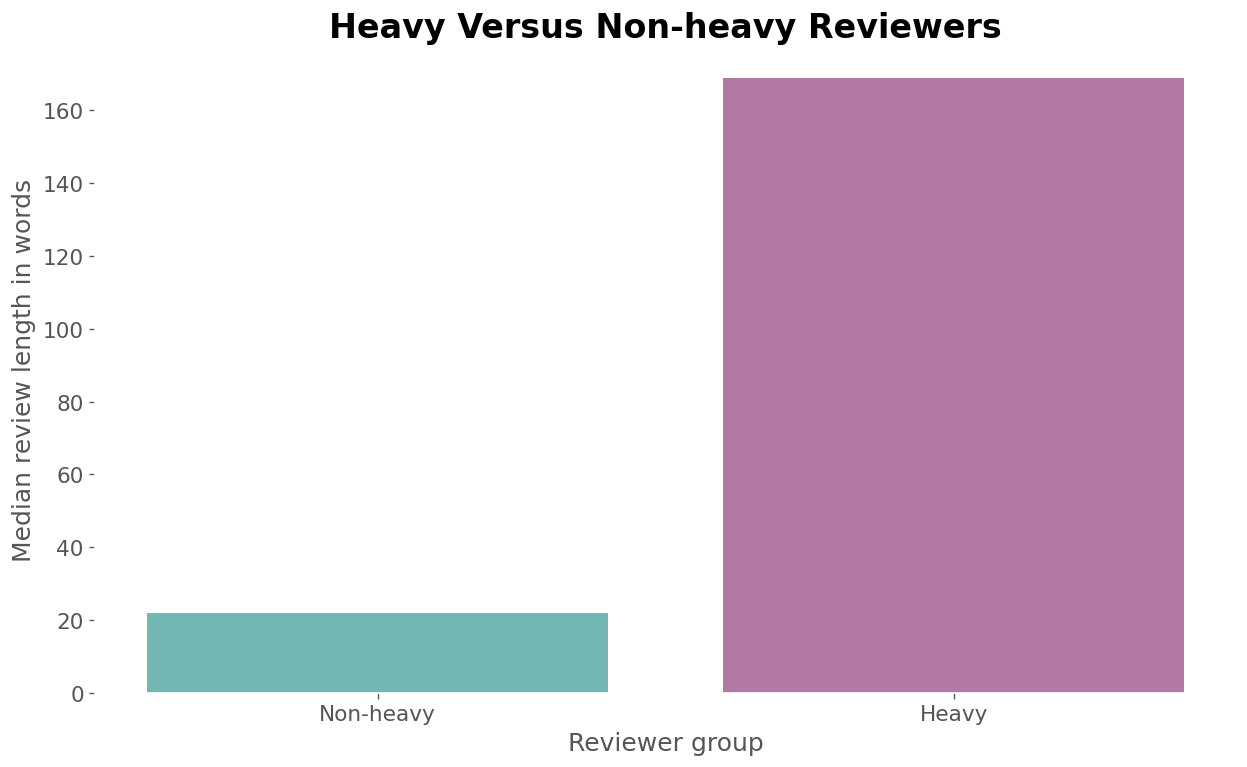

In [31]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(heavy_labels, median_length_by_heavy.values, color=["#72B7B2", "#B279A2"])
ax.set_title("Heavy Versus Non-heavy Reviewers")
ax.set_xlabel("Reviewer group")
ax.set_ylabel("Median review length in words")
final_axis_cleanup(ax)
fig.tight_layout()
save_figure(fig, "median_review_length_heavy_vs_nonheavy.png")

slide_fig, slide_ax = plt.subplots(figsize=SLIDE_FIGSIZE)
slide_ax.bar(heavy_labels, median_length_by_heavy.values, color=["#72B7B2", "#B279A2"])
slide_ax.set_title("Heavy Versus Non-heavy Reviewers")
slide_ax.set_xlabel("Reviewer group")
slide_ax.set_ylabel("Median review length in words")
slide_ax.tick_params(labelsize=13)
slide_ax.title.set_fontsize(20)
slide_ax.xaxis.label.set_size(15)
slide_ax.yaxis.label.set_size(15)
final_axis_cleanup(slide_ax)
slide_fig.tight_layout()
save_figure(slide_fig, "slide_heavy_vs_nonheavy_length.png", slide=True)
plt.show()


*Caption:* Reviewer activity is strongly linked to writing behavior. Frequent reviewers contribute much longer comments on average, suggesting that reviewing intensity and review elaboration go together.

## Figure 9. Rating by Review Length Group

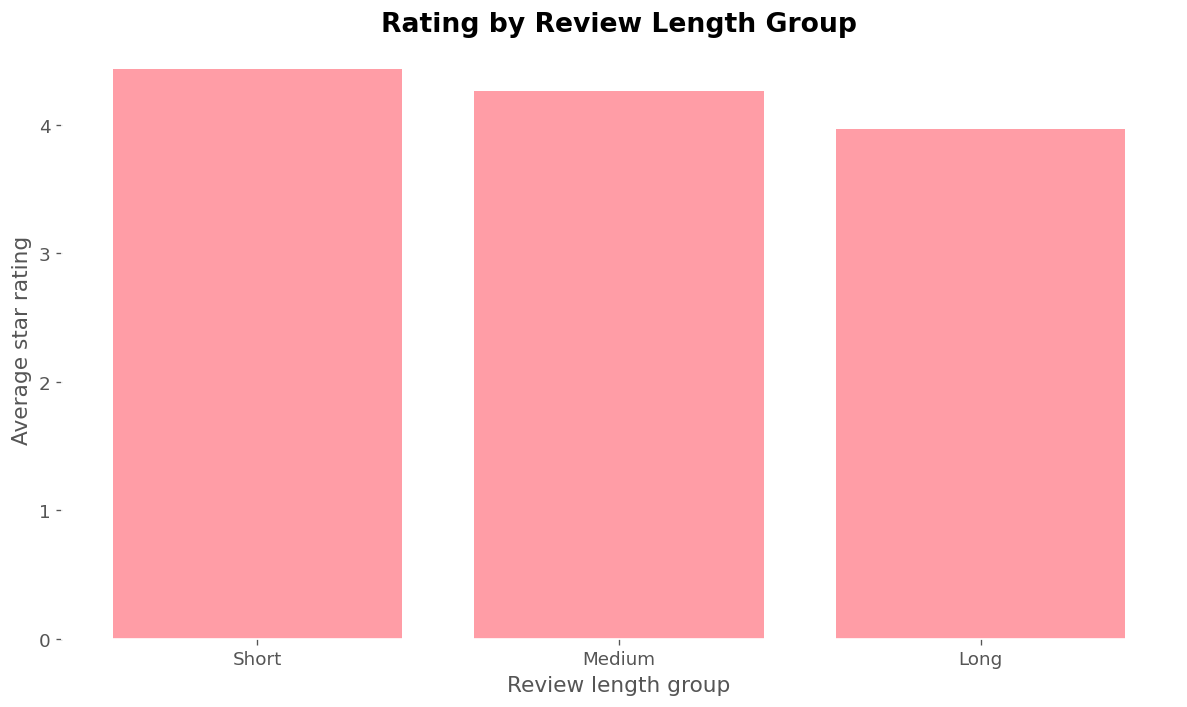

In [32]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(average_rating_by_length.index.astype(str), average_rating_by_length.values, color="#FF9DA6")
ax.set_title("Rating by Review Length Group")
ax.set_xlabel("Review length group")
ax.set_ylabel("Average star rating")
final_axis_cleanup(ax)
fig.tight_layout()
save_figure(fig, "average_rating_by_length_group.png")
plt.show()


*Caption:* Grouping reviews into short, medium, and long comments provides a simple behavioral comparison. Longer review groups tend to rate items somewhat less positively on average.

## Statistical Tests

The dataset is very large, so very small effects can produce extremely small p-values. For that reason, each result below reports both statistical evidence and a practical interpretation.

In [15]:
def effect_label(value: float) -> str:
    magnitude = abs(value)
    if magnitude < 0.10:
        return "very small"
    if magnitude < 0.30:
        return "small"
    if magnitude < 0.50:
        return "moderate"
    return "large"


def rank_biserial_from_u(u_stat: float, n1: int, n2: int) -> float:
    return 1 - (2 * u_stat) / (n1 * n2)


def epsilon_squared_kruskal(h_stat: float, k_groups: int, n_total: int) -> float:
    return max(0.0, (h_stat - k_groups + 1) / (n_total - k_groups))


test_results = []


def append_test_result(test_name: str, statistic: float, p_value: float, effect_size: float, practical_interpretation: str, conclusion: str):
    test_results.append(
        {
            "test_name": test_name,
            "statistic": statistic,
            "p_value": p_value,
            "effect_size": effect_size,
            "practical_interpretation": practical_interpretation,
            "conclusion": conclusion,
        }
    )
    print(f"\n{test_name}")
    print(f"Statistic: {statistic:,.4f}")
    print(f"p-value: {p_value:,.4g}")
    print(f"Effect size / practical interpretation: {practical_interpretation}")
    print(f"Plain-English conclusion: {conclusion}")


rho_rating, p_rating = stats.spearmanr(df["review_length_words"], df["rating"], nan_policy="omit")
append_test_result(
    "Spearman correlation: review length vs rating",
    float(rho_rating),
    float(p_rating),
    float(rho_rating),
    f"Spearman rho = {rho_rating:,.3f}, which is a {effect_label(rho_rating)} monotonic association.",
    "Review length and rating are related, but the correlation size should be judged as a behavioral tendency rather than a strong predictive relationship."
)

rho_helpful, p_helpful = stats.spearmanr(df["review_length_words"], df["helpful_votes"], nan_policy="omit")
append_test_result(
    "Spearman correlation: review length vs helpful votes",
    float(rho_helpful),
    float(p_helpful),
    float(rho_helpful),
    f"Spearman rho = {rho_helpful:,.3f}, which is a {effect_label(rho_helpful)} positive association.",
    "Longer reviews tend to receive more helpful votes, and this relationship is substantively more meaningful than a near-zero correlation would be."
)

verified_lengths = df.loc[df["verified"], "review_length_words"]
unverified_lengths = df.loc[~df["verified"], "review_length_words"]
mw_verified = stats.mannwhitneyu(verified_lengths, unverified_lengths, alternative="two-sided")
verified_rbc = rank_biserial_from_u(float(mw_verified.statistic), len(verified_lengths), len(unverified_lengths))
verified_median = float(verified_lengths.median())
unverified_median = float(unverified_lengths.median())
append_test_result(
    "Mann-Whitney U: verified vs unverified review length",
    float(mw_verified.statistic),
    float(mw_verified.pvalue),
    float(verified_rbc),
    f"Rank-biserial effect size = {verified_rbc:,.3f}; medians are {verified_median:,.1f} words for verified reviews and {unverified_median:,.1f} words for unverified reviews.",
    "Verified and unverified reviews differ meaningfully in typical length, and the median gap is more informative than the p-value alone."
)

heavy_lengths = df.loc[df["heavy_reviewer"], "review_length_words"]
nonheavy_lengths = df.loc[~df["heavy_reviewer"], "review_length_words"]
mw_heavy = stats.mannwhitneyu(heavy_lengths, nonheavy_lengths, alternative="two-sided")
heavy_rbc = rank_biserial_from_u(float(mw_heavy.statistic), len(heavy_lengths), len(nonheavy_lengths))
heavy_median = float(heavy_lengths.median())
nonheavy_median = float(nonheavy_lengths.median())
append_test_result(
    "Mann-Whitney U: heavy vs non-heavy reviewer length",
    float(mw_heavy.statistic),
    float(mw_heavy.pvalue),
    float(heavy_rbc),
    f"Rank-biserial effect size = {heavy_rbc:,.3f}; medians are {heavy_median:,.1f} words for heavy reviewers and {nonheavy_median:,.1f} words for non-heavy reviewers.",
    "Heavy reviewers write much longer comments on median, indicating a practically large behavioral difference between reviewer activity groups."
)

rating_groups_for_test = [df.loc[df["rating"] == rating, "review_length_words"] for rating in sorted(df["rating"].unique())]
kw_rating = stats.kruskal(*rating_groups_for_test)
kw_epsilon = epsilon_squared_kruskal(float(kw_rating.statistic), len(rating_groups_for_test), len(df))
append_test_result(
    "Kruskal-Wallis: review length across rating groups",
    float(kw_rating.statistic),
    float(kw_rating.pvalue),
    float(kw_epsilon),
    f"Epsilon-squared = {kw_epsilon:,.3f}, which suggests a {effect_label(kw_epsilon)} group effect overall.",
    "At least one rating group differs in review length, but the effect size and the group medians are more useful than the p-value for judging substantive importance."
)

statistical_tests_summary = pd.DataFrame(test_results)
statistical_tests_summary.to_csv(OUTPUT_DIR / "statistical_tests_summary.csv", index=False)
display(statistical_tests_summary)
print("Note: with millions of reviews, statistical significance can occur even when behavioral differences are small.")



Spearman correlation: review length vs rating
Statistic: -0.1907
p-value: 0
Effect size / practical interpretation: Spearman rho = -0.191, which is a small monotonic association.
Plain-English conclusion: Review length and rating are related, but the correlation size should be judged as a behavioral tendency rather than a strong predictive relationship.

Spearman correlation: review length vs helpful votes
Statistic: 0.4974
p-value: 0
Effect size / practical interpretation: Spearman rho = 0.497, which is a moderate positive association.
Plain-English conclusion: Longer reviews tend to receive more helpful votes, and this relationship is substantively more meaningful than a near-zero correlation would be.

Mann-Whitney U: verified vs unverified review length
Statistic: 407,329,387,773.5000
p-value: 0
Effect size / practical interpretation: Rank-biserial effect size = 0.641; medians are 18.0 words for verified reviews and 112.0 words for unverified reviews.
Plain-English conclusion: Ver

,test_name,statistic,p_value,effect_size,practical_interpretation,conclusion
0,Spearman correlation: review length vs rating,-0.1907,0.0000,-0.1907,"Spearman rho = -0.191, which is a small monoto...","Review length and rating are related, but the ..."
1,Spearman correlation: review length vs helpful...,0.4974,0.0000,0.4974,"Spearman rho = 0.497, which is a moderate posi...",Longer reviews tend to receive more helpful vo...
2,Mann-Whitney U: verified vs unverified review ...,"407,329,387,773.5000",0.0000,0.6411,Rank-biserial effect size = 0.641; medians are...,Verified and unverified reviews differ meaning...
3,Mann-Whitney U: heavy vs non-heavy reviewer le...,"831,898,027,120.0000",0.0000,-0.5845,Rank-biserial effect size = -0.585; medians ar...,Heavy reviewers write much longer comments on ...
4,Kruskal-Wallis: review length across rating gr...,"127,313.4098",0.0000,0.0373,"Epsilon-squared = 0.037, which suggests a very...",At least one rating group differs in review le...


Note: with millions of reviews, statistical significance can occur even when behavioral differences are small.


## Regression Model

The regression model evaluates whether longer reviews are associated with more helpful votes after controlling for rating, verified status, and year.

`log_helpful_votes ~ log_review_length_words + rating + verified + year`

The dependent variable uses `log1p` because helpful-vote counts are heavily right-skewed and include many zeros.

In [16]:
model_df = df[["log_helpful_votes", "log_review_length_words", "rating", "verified", "year"]].dropna().copy()
model_df["verified"] = model_df["verified"].astype(int)

print(f"Rows used in regression: {len(model_df):,}")

X = sm.add_constant(model_df[["log_review_length_words", "rating", "verified", "year"]])
y = model_df["log_helpful_votes"]

ols_model = sm.OLS(y, X).fit(cov_type="HC3")
print(ols_model.summary())

coef_length = float(ols_model.params["log_review_length_words"])
p_length = float(ols_model.pvalues["log_review_length_words"])
ci_low, ci_high = ols_model.conf_int().loc["log_review_length_words"]

regression_coefficients_summary = (
    pd.DataFrame(
        {
            "term": ols_model.params.index,
            "coefficient": ols_model.params.values,
            "std_error": ols_model.bse.values,
            "z_or_t_stat": ols_model.tvalues.values,
            "p_value": ols_model.pvalues.values,
            "ci_lower": ols_model.conf_int()[0].values,
            "ci_upper": ols_model.conf_int()[1].values,
        }
    )
)
regression_coefficients_summary.to_csv(OUTPUT_DIR / "regression_coefficients_summary.csv", index=False)

print("\nCompact interpretation of the review-length coefficient")
print(f"Coefficient on log_review_length_words: {coef_length:,.4f}")
print(f"95% confidence interval: [{ci_low:,.4f}, {ci_high:,.4f}]")
print(f"p-value: {p_length:,.4g}")

if coef_length > 0:
    print("Conclusion: After controlling for rating, verified status, and year, longer reviews are associated with more helpful votes.")
elif coef_length < 0:
    print("Conclusion: After controlling for rating, verified status, and year, longer reviews are associated with fewer helpful votes.")
else:
    print("Conclusion: After controlling for rating, verified status, and year, review length has essentially no conditional association with helpful votes.")

print(
    "Interpretation note: because the model uses log1p transformations, the coefficient can be read as an approximate elasticity-style relationship away from zero. "
    "Also, with a dataset this large, even very small coefficients can be statistically significant, so the effect size matters more than p-values alone."
)
display(regression_coefficients_summary)


Rows used in regression: 3,410,019
                            OLS Regression Results                            
Dep. Variable:      log_helpful_votes   R-squared:                       0.297
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                 1.859e+05
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        23:29:25   Log-Likelihood:            -3.3725e+06
No. Observations:             3410019   AIC:                         6.745e+06
Df Residuals:                 3410014   BIC:                         6.745e+06
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

,term,coefficient,std_error,z_or_t_stat,p_value,ci_lower,ci_upper
0,const,117.9284,0.3659,322.2633,0.0000,117.2112,118.6456
1,log_review_length_words,0.1677,0.0004,470.0897,0.0000,0.1670,0.1684
2,rating,-0.0404,0.0004,-112.5963,0.0000,-0.0411,-0.0397
3,verified,0.0154,0.0012,12.9538,0.0000,0.0131,0.0177
4,year,-0.0586,0.0002,-322.6744,0.0000,-0.0590,-0.0582


## Presentation Results

In [17]:
median_length = float(df["review_length_words"].median())
mean_length = float(df["review_length_words"].mean())
top_rating_median = int(median_length_by_rating.idxmax())
bottom_rating_median = int(median_length_by_rating.idxmin())
year_start = int(yearly_review_length_summary["year"].min())
year_end = int(yearly_review_length_summary["year"].max())
year_start_median = float(yearly_review_length_summary.loc[yearly_review_length_summary["year"] == year_start, "median_review_length_words"].iloc[0])
year_end_median = float(yearly_review_length_summary.loc[yearly_review_length_summary["year"] == year_end, "median_review_length_words"].iloc[0])
early_year_count = int(yearly_review_length_summary.loc[yearly_review_length_summary["year"] == year_start, "yearly_review_count"].iloc[0])
late_year_count = int(yearly_review_length_summary.loc[yearly_review_length_summary["year"] == year_end, "yearly_review_count"].iloc[0])

if year_end_median > year_start_median:
    time_trend_text = "increased over time"
elif year_end_median < year_start_median:
    time_trend_text = "declined over time"
else:
    time_trend_text = "stayed broadly stable over time"

presentation_md = f"""
- The overall distribution of review length is strongly right-skewed, with a **median of {median_length:,.1f} words** and a **mean of {mean_length:,.1f} words**.
- The **{top_rating_median}-star** group has the longest median review length, while the **{bottom_rating_median}-star** group has the shortest median review length.
- The Spearman correlation between review length and helpful votes is **{rho_helpful:,.3f}**, indicating a positive relationship between longer comments and helpfulness.
- Verified reviews have a median length of **{verified_median:,.1f} words**, compared with **{unverified_median:,.1f} words** for unverified reviews.
- Heavy reviewers have a median length of **{heavy_median:,.1f} words**, compared with **{nonheavy_median:,.1f} words** for non-heavy reviewers.
- Review length **{time_trend_text}**, moving from **{year_start_median:,.1f} words in {year_start}** to **{year_end_median:,.1f} words in {year_end}**.
- A key caveat is that the earliest year in the dataset has only **{early_year_count:,} reviews**, compared with **{late_year_count:,} reviews** in the final year, so early-year medians should be interpreted cautiously.
- For the group project, review length adds a text-based behavioral signal that complements analyses of ratings, reviewer activity, harshness, and negative review concentration.
"""

display(Markdown(presentation_md))



- The overall distribution of review length is strongly right-skewed, with a **median of 25.0 words** and a **mean of 81.1 words**.
- The **2-star** group has the longest median review length, while the **5-star** group has the shortest median review length.
- The Spearman correlation between review length and helpful votes is **0.497**, indicating a positive relationship between longer comments and helpfulness.
- Verified reviews have a median length of **18.0 words**, compared with **112.0 words** for unverified reviews.
- Heavy reviewers have a median length of **169.0 words**, compared with **22.0 words** for non-heavy reviewers.
- Review length **declined over time**, moving from **263.0 words in 1997** to **10.0 words in 2018**.
- A key caveat is that the earliest year in the dataset has only **1 reviews**, compared with **92,104 reviews** in the final year, so early-year medians should be interpreted cautiously.
- For the group project, review length adds a text-based behavioral signal that complements analyses of ratings, reviewer activity, harshness, and negative review concentration.


## Final Slide Content for Timothy's Section

In [18]:
longest_rating = int(median_length_by_rating.idxmax())
shortest_rating = int(median_length_by_rating.idxmin())
longest_rating_median = float(median_length_by_rating.loc[longest_rating])
shortest_rating_median = float(median_length_by_rating.loc[shortest_rating])

timothy_slide_md = f"""
### Slide 1
**Slide title:** Review Length as a Behavioral Signal

**Bullets:**
- Review length captures how much explanation a reviewer chooses to provide.
- It varies across ratings, helpfulness, verification status, and reviewer activity.
- That makes length a useful behavioral signal alongside star ratings.
- It adds a text-based view of reviewer engagement to the broader project.

**Recommended figure file:** `slide_review_length_by_rating.png`

**Speaker script (30-45 seconds):** Review length is useful here because it reflects how much detail or effort reviewers put into their comments. In this notebook, length is associated with multiple review characteristics, including rating, helpfulness, verification status, and reviewer activity. That means it gives us more behavioral information than the star score alone. For the project, it works as a simple but informative text-based signal of how people choose to express their opinions.

### Slide 2
**Slide title:** Review Length Distribution and Skew

**Bullets:**
- Review length is strongly right-skewed.
- Median length is **{median_length:,.1f} words**, while mean length is **{mean_length:,.1f} words**.
- Most reviews are short, but a small share are extremely long.
- Because of this skew, medians are often the better summary of a typical review.

**Recommended figure file:** `slide_review_length_distribution.png`

**Speaker script (30-45 seconds):** The distribution shows a clear skew in review length. The typical review is short, with a median of {median_length:,.1f} words, but the mean is much higher at {mean_length:,.1f} words because a smaller group of very long reviews stretches the distribution to the right. That is why medians matter so much in the rest of this section. They describe the center of the data better than averages when a few long comments can heavily influence the mean.

### Slide 3
**Slide title:** Review Length by Rating and Helpfulness

**Bullets:**
- Review length and rating show a weak negative association (**Spearman rho = {rho_rating:,.3f}**).
- The **{longest_rating}-star** group has the longest median review length (**{longest_rating_median:,.1f} words**).
- The **{shortest_rating}-star** group has the shortest median review length (**{shortest_rating_median:,.1f} words**).
- Longer reviews are also associated with more helpful votes (**Spearman rho = {rho_helpful:,.3f}**).

**Recommended figure file:** `slide_review_length_vs_helpful_votes.png`

**Speaker script (30-45 seconds):** Review length is not distributed evenly across outcomes. Lower ratings tend to be associated with longer reviews, while the shortest typical reviews appear in the {shortest_rating}-star group. At the same time, longer reviews are moderately associated with more helpful votes, with a Spearman correlation of {rho_helpful:,.3f}. Together, those patterns suggest that review length is linked both to how people evaluate a product and to how useful other readers seem to find the review.

### Slide 4
**Slide title:** Reviewer-Type Differences in Review Length

**Bullets:**
- Verified reviews have a median length of **{verified_median:,.1f} words**.
- Unverified reviews have a median length of **{unverified_median:,.1f} words**.
- Heavy reviewers have a median length of **{heavy_median:,.1f} words**.
- Non-heavy reviewers have a median length of **{nonheavy_median:,.1f} words**.
- Review length differs sharply across reviewer types.

**Recommended figure file:** `slide_verified_vs_unverified_length.png` and `slide_heavy_vs_nonheavy_length.png`

**Speaker script (30-45 seconds):** Reviewer type is strongly associated with comment length. Verified reviews are much shorter on average than unverified reviews, and heavy reviewers write much longer reviews than non-heavy reviewers. The median gaps are large enough to stand out clearly even without focusing on formal significance tests. For presentation purposes, this is one of the strongest takeaways in the notebook: who is writing the review is closely associated with how much they write.
"""

display(Markdown(timothy_slide_md))



### Slide 1
**Slide title:** Review Length as a Behavioral Signal

**Bullets:**
- Review length captures how much explanation a reviewer chooses to provide.
- It varies across ratings, helpfulness, verification status, and reviewer activity.
- That makes length a useful behavioral signal alongside star ratings.
- It adds a text-based view of reviewer engagement to the broader project.

**Recommended figure file:** `slide_review_length_by_rating.png`

**Speaker script (30-45 seconds):** Review length is useful here because it reflects how much detail or effort reviewers put into their comments. In this notebook, length is associated with multiple review characteristics, including rating, helpfulness, verification status, and reviewer activity. That means it gives us more behavioral information than the star score alone. For the project, it works as a simple but informative text-based signal of how people choose to express their opinions.

### Slide 2
**Slide title:** Review Length Distribution and Skew

**Bullets:**
- Review length is strongly right-skewed.
- Median length is **25.0 words**, while mean length is **81.1 words**.
- Most reviews are short, but a small share are extremely long.
- Because of this skew, medians are often the better summary of a typical review.

**Recommended figure file:** `slide_review_length_distribution.png`

**Speaker script (30-45 seconds):** The distribution shows a clear skew in review length. The typical review is short, with a median of 25 words, but the mean is much higher at 81.1 words because a smaller group of very long reviews stretches the distribution to the right. That is why medians matter so much in the rest of this section. They describe the center of the data better than averages when a few long comments can heavily influence the mean.

### Slide 3
**Slide title:** Review Length by Rating and Helpfulness

**Bullets:**
- Review length and rating show a weak negative association (**Spearman rho = -0.191**).
- The **2-star** group has the longest median review length (**51.0 words**).
- The **5-star** group has the shortest median review length (**16.0 words**).
- Longer reviews are also associated with more helpful votes (**Spearman rho = 0.497**).

**Recommended figure file:** `slide_review_length_vs_helpful_votes.png`

**Speaker script (30-45 seconds):** Review length is not distributed evenly across outcomes. Lower ratings tend to be associated with longer reviews, while the shortest typical reviews appear in the 5-star group. At the same time, longer reviews are moderately associated with more helpful votes, with a Spearman correlation of 0.497. Together, those patterns suggest that review length is linked both to how people evaluate a product and to how useful other readers seem to find the review.

### Slide 4
**Slide title:** Reviewer-Type Differences in Review Length

**Bullets:**
- Verified reviews have a median length of **18.0 words**.
- Unverified reviews have a median length of **112.0 words**.
- Heavy reviewers have a median length of **169.0 words**.
- Non-heavy reviewers have a median length of **22.0 words**.
- Review length differs sharply across reviewer types.

**Recommended figure file:** `slide_verified_vs_unverified_length.png` and `slide_heavy_vs_nonheavy_length.png`

**Speaker script (30-45 seconds):** Reviewer type is strongly associated with comment length. Verified reviews are much shorter on average than unverified reviews, and heavy reviewers write much longer reviews than non-heavy reviewers. The median gaps are large enough to stand out clearly even without focusing on formal significance tests. For presentation purposes, this is one of the strongest takeaways in the notebook: who is writing the review is closely associated with how much they write.


## Validation Checks

The final cell confirms that the notebook generated the required outputs and retained the expected analysis columns.

In [19]:
required_columns = [
    "rating",
    "review_text",
    "summary_text",
    "date",
    "year",
    "helpful_votes",
    "review_length_chars",
    "review_length_words",
    "summary_length_words",
    "log_review_length_words",
    "log_helpful_votes",
    "reviewer_review_count",
    "item_review_count",
    "heavy_reviewer",
    "length_group",
]

missing_columns = [col for col in required_columns if col not in df.columns]
missing_main_png = [name for name in MAIN_PNG_FILES if not (OUTPUT_DIR / name).exists()]
missing_slide_png = [name for name in SLIDE_PNG_FILES if not (SLIDE_DIR / name).exists()]
missing_csv = [name for name in CSV_FILES if not (OUTPUT_DIR / name).exists()]

print(f"Row count after cleaning: {len(df):,}")
print(f"Model row count: {len(model_df):,}")
print(f"Missing analysis columns: {missing_columns}")
print(f"Missing main PNG files: {missing_main_png}")
print(f"Missing slide PNG files: {missing_slide_png}")
print(f"Missing CSV files: {missing_csv}")

if missing_columns:
    raise AssertionError(f"Missing required analysis columns: {missing_columns}")
if missing_main_png:
    raise AssertionError(f"Missing expected main PNG files: {missing_main_png}")
if missing_slide_png:
    raise AssertionError(f"Missing expected slide PNG files: {missing_slide_png}")
if missing_csv:
    raise AssertionError(f"Missing expected CSV files: {missing_csv}")

print("Validation passed: all expected figures, tables, and analysis columns are present.")


Row count after cleaning: 3,410,019
Model row count: 3,410,019
Missing analysis columns: []
Missing main PNG files: []
Missing slide PNG files: []
Missing CSV files: []
Validation passed: all expected figures, tables, and analysis columns are present.
